In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import torch
import numpy as np
import cupy as cp
import time

# Import your custom modules
from laser_generator import LaserProfileGenerator
from thermomechanical import run_coupled_simulation

# --- CONFIGURATION ---
SIM_DURATION = 121.1  # Ensure this matches your .crs file duration
PROPERTIES_DIR = "."
GEOM_FILE = "thinwall.k"
OUTPUT_ZARR = "debug_stress.zarr"
cp.cuda.Device(2).use()



<CUDA Device 2>

In [3]:
import zarr
import pyvista as pv
import numpy as np
import vtk
from gamma.simulator.gamma import domain_mgr

def convert_zarr_to_vtk_dynamic(zarr_dir, k_file, output_prefix, target_outputs=100):
    print(f"Reading mesh from: {k_file}")
    domain = domain_mgr(filename=k_file)
    
    # 1. Pull all mesh data down to the CPU
    nodes = domain.nodes.get() if hasattr(domain.nodes, 'get') else domain.nodes
    elements = domain.elements.get() if hasattr(domain.elements, 'get') else domain.elements
    
    # Pull the birth arrays to determine what is active
    node_birth = domain.node_birth.get() if hasattr(domain.node_birth, 'get') else domain.node_birth
    element_birth = domain.element_birth.get() if hasattr(domain.element_birth, 'get') else domain.element_birth
    
    print(f"Reading Zarr store from: {zarr_dir}")
    root = zarr.open(zarr_dir, mode='r')
    
    time_array = root['time'][:]
    num_steps = len(time_array)
    
    # Downsampling logic
    interval = max(1, num_steps // target_outputs)
    steps_to_process = list(range(0, num_steps, interval))
    if steps_to_process[-1] != num_steps - 1:
        steps_to_process.append(num_steps - 1)
        
    print(f"Downsampled Zarr to {len(steps_to_process)} frames.")

    for step in steps_to_process:
        current_time = time_array[step]
        print(f"Processing step {step}/{num_steps - 1} (Sim Time: {current_time:.4f}s)...")
        
        # --- DYNAMIC MESH LOGIC ---
        # 1. Create masks for nodes and elements born before the current time
        active_n_mask = node_birth <= current_time
        active_e_mask = element_birth <= current_time
        
        # 2. Extract active nodes and displacements
        U = root['U'][step]
        U_active = U[active_n_mask]
        points_active = nodes[active_n_mask] + 5 * U_active 
        
        # 3. Remap Element Connectivity (CRITICAL)
        global_elements_active = elements[active_e_mask]
        
        # Create a mapping array from Global ID -> Local ID
        node_map = np.full(len(nodes), -1)
        node_map[active_n_mask] = np.arange(np.sum(active_n_mask))
        
        # Apply the map to the active elements
        local_elements_active = node_map[global_elements_active]
        
        # Fast vectorized way to build PyVista cells: [8, p1, p2, p3, p4, p5, p6, p7, p8]
        active_cells = np.hstack((np.full((len(local_elements_active), 1), 8), local_elements_active)).flatten()
        active_cell_type = np.array([vtk.VTK_HEXAHEDRON] * len(local_elements_active))
        
        # Initialize Grid
        grid = pv.UnstructuredGrid(active_cells, active_cell_type, points_active)
        
        # Assign Point Data (only to active nodes)
        grid.point_data['temp'] = root['temperature'][step][active_n_mask]
        grid.point_data['U1'] = U_active[:, 0]
        grid.point_data['U2'] = U_active[:, 1]
        grid.point_data['U3'] = U_active[:, 2]

        # Assign Cell Data (only to active elements)
        S_ip = root['stress'][step]
        S_ip_active = S_ip[active_e_mask]
        S_avg = np.mean(S_ip_active, axis=1) 
        
        grid.cell_data['S11'] = S_avg[:, 0]
        grid.cell_data['S22'] = S_avg[:, 1]
        grid.cell_data['S33'] = S_avg[:, 2]
        grid.cell_data['S12'] = S_avg[:, 3]
        grid.cell_data['S23'] = S_avg[:, 4]
        grid.cell_data['S13'] = S_avg[:, 5]

        Sv = np.sqrt(0.5 * ((S_avg[:,0]-S_avg[:,1])**2 + (S_avg[:,1]-S_avg[:,2])**2 + (S_avg[:,2]-S_avg[:,0])**2 + 6*(S_avg[:,3]**2 + S_avg[:,4]**2 + S_avg[:,5]**2)))
        grid.cell_data['S_von'] = Sv

        grid.save(f"output/{output_prefix}_{step}.vtk")
        
    print("Done!")

# Execution
convert_zarr_to_vtk_dynamic('./debug_stress.zarr', 'wall.k', 'output_mesh', target_outputs=1500)

Reading mesh from: wall.k


FileNotFoundError: ././materials/IN718_cp.txt not found.

In [3]:
import zarr
import pyvista as pv
import numpy as np
import vtk
from gamma.simulator.gamma import domain_mgr
def evaluate_objectives_from_zarr(zarr_dir, k_file):
    print(f"\n--- EVALUATING OBJECTIVES FROM ZARR ---")
    print(f"Reading mesh from: {k_file}")
    domain = domain_mgr(filename=k_file)
    
    # Extract birth arrays to CPU
    element_birth = domain.element_birth.get() if hasattr(domain.element_birth, 'get') else domain.element_birth
    node_birth = domain.node_birth.get() if hasattr(domain.node_birth, 'get') else domain.node_birth
    
    print(f"Reading Zarr store from: {zarr_dir}")
    root = zarr.open(zarr_dir, mode='r')
    
    # Get the time array and find the final simulation time
    time_array = np.array(root['time'][:]).flatten()
    final_time = time_array[-1]
    
    # Determine which nodes and elements physically exist at the end
    deposit_e_mask = (element_birth > 1e-5) & (element_birth <= final_time)
    deposit_n_mask = (node_birth > 1e-5) & (node_birth <= final_time)
    
    print(f"Final Sim Time: {final_time:.4f}s")
    print(f"Deposited Elements: {np.sum(deposit_e_mask)} / {len(element_birth)}")
    print(f"Deposited Nodes: {np.sum(deposit_n_mask)} / {len(node_birth)}")

    # ==========================================
    # 1. RESIDUAL STRESS OBJECTIVES
    # ==========================================
    print("Calculating Residual Stress Objectives...")
    # Get the stress state from the final recorded timestep
    S_final_all = np.array(root['stress'][-1]) # Shape: [n_elements, n_ip, 6]
    
    # Filter to only the active elements
    S_final = S_final_all[deposit_e_mask]
    
    # Calculate Von Mises on all integration points (Exact simulator logic)
    S_vm = np.sqrt(0.5 * ((S_final[:,:,0]-S_final[:,:,1])**2 + 
                          (S_final[:,:,1]-S_final[:,:,2])**2 + 
                          (S_final[:,:,2]-S_final[:,:,0])**2 + 
                          6*(S_final[:,:,3]**2 + S_final[:,:,4]**2 + S_final[:,:,5]**2)))
    
    max_residual_stress = float(np.max(S_vm))
    avg_residual_stress = float(np.mean(S_vm))

    # ==========================================
    # 2. HEAT TREATMENT TIME OBJECTIVES
    # ==========================================
    print("Calculating Heat Treatment Objectives...")
    T_MIN_HT = 654.0 + 273.15  # IN718 Min (Kelvin)
    T_MAX_HT = 857.0 + 273.15  # IN718 Max (Kelvin)
    
    # Load the entire temperature history [time_steps, total_nodes]
    T_history = np.array(root['temperature'][:])
    
    # Boolean mask for the critical temperature window
    in_range = (T_history >= T_MIN_HT) & (T_history <= T_MAX_HT)
    t_history_2d = time_array[:, np.newaxis]
    
    # Find LAST time in range
    t_max_masked = np.where(in_range, t_history_2d, -1.0)
    last_time_in_range = np.max(t_max_masked, axis=0)
    
    # Find FIRST time in range
    t_min_masked = np.where(in_range, t_history_2d, np.inf)
    first_time_in_range = np.min(t_min_masked, axis=0)
    
    # Calculate duration
    valid_nodes = last_time_in_range >= first_time_in_range
    ht_durations = np.zeros(len(node_birth), dtype=np.float64)
    ht_durations[valid_nodes] = last_time_in_range[valid_nodes] - first_time_in_range[valid_nodes]
    
    # Isolate physically active nodes
    active_ht_durations = ht_durations[deposit_n_mask]
    
    avg_heat_treatment_time = float(np.mean(active_ht_durations))
    min_heat_treatment_time = float(np.min(active_ht_durations))

    # --- PRINT RESULTS ---
    print("\n" + "="*40)
    print("FINAL OBJECTIVE EVALUATION")
    print("="*40)
    print(f"Max Residual Stress: {max_residual_stress:.2f} MPa")
    print(f"Avg Residual Stress: {avg_residual_stress:.2f} MPa")
    print(f"Avg Heat Treatment:  {avg_heat_treatment_time:.4f} seconds")
    print(f"Min Heat Treatment:  {min_heat_treatment_time:.4f} seconds")
    print("="*40 + "\n")

    return max_residual_stress, avg_residual_stress, avg_heat_treatment_time, min_heat_treatment_time

# Execute the evaluator
evaluate_objectives_from_zarr('./stress_history_eval_89.zarr', 'thinwall.k')


--- EVALUATING OBJECTIVES FROM ZARR ---
Reading mesh from: thinwall.k
Time of reading input files: 0.2536137104034424
Time of calculating critical timestep: 0.02315521240234375
Time of reading and interpolating toolpath: 0.05909276008605957
Number of nodes: 23249
Number of elements: 19076
Number of time-steps: 168200
Time of generating surface: 0.10607075691223145
Reading Zarr store from: ./stress_history_eval_89.zarr
Final Sim Time: 84.0805s
Deposited Elements: 11200 / 19076
Deposited Nodes: 13632 / 23249
Calculating Residual Stress Objectives...
Calculating Heat Treatment Objectives...

FINAL OBJECTIVE EVALUATION
Max Residual Stress: 299.23 MPa
Avg Residual Stress: 146.78 MPa
Avg Heat Treatment:  8.4340 seconds
Min Heat Treatment:  0.0000 seconds



(299.22943115234375, 146.77964782714844, 8.433998232716126, 0.0)

In [1]:
import torch
from botorch.utils.multi_objective.pareto import is_non_dominated

# --- 1. Load the Final Checkpoint ---
# Change this to your highest iteration checkpoint file
CHECKPOINT_FILE = "bo_checkpoint_iter_12.pt" 
checkpoint = torch.load(CHECKPOINT_FILE)

train_X = checkpoint['train_X']
train_Y = checkpoint['train_Y']

# --- 2. Filter for Feasible Solutions ---
# Recall your Y indices: 
# 0: -avg_stress, 1: avg_ht, 2: min_ht, 3: max_stress
# Constraints: min_ht >= 15.0, max_stress <= 1200.0

S_MAX = 1200.0

c2_valid = train_Y[:, 3] <= S_MAX
is_feasible = c2_valid

feasible_X = train_X[is_feasible]
feasible_Y = train_Y[is_feasible]

if len(feasible_X) == 0:
    print("Optimization failed to find any physically feasible solutions.")
else:
    print(f"Found {len(feasible_X)} feasible evaluations. Calculating Pareto front...\n")
    
    # --- 3. Identify the Pareto Front ---
    # We extract just the objectives (0 and 1)
    # BoTorch's `is_non_dominated` assumes we want to MAXIMIZE all objectives.
    # Since Y[0] is -avg_stress, maximizing it correctly minimizes the real stress.
    objectives = feasible_Y[:, 0:2]
    pareto_mask = is_non_dominated(objectives)
    
    best_X = feasible_X[pareto_mask]
    best_Y = feasible_Y[pareto_mask]
    
    # --- 4. Output the Best Results ---
    print(f"=== {len(best_X)} PARETO OPTIMAL SOLUTIONS FOUND ===\n")
    
    for i in range(len(best_X)):
        # Revert the negative sign on average stress for readability
        true_avg_stress = -best_Y[i, 0].item()
        avg_ht = best_Y[i, 1].item()
        min_ht = best_Y[i, 2].item()
        max_stress = best_Y[i, 3].item()
        
        print(f"Solution {i+1}:")
        print(f"  Objectives  -> Avg Stress: {true_avg_stress:.2f} MPa | Avg HT: {avg_ht:.2f} s")
        print(f"  Constraints -> Max Stress: {max_stress:.2f} MPa | Min HT: {min_ht:.2f} s")
        print(f"  Parameters  -> {best_X[i].numpy().round(4)}\n")

/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 34 feasible evaluations. Calculating Pareto front...

=== 6 PARETO OPTIMAL SOLUTIONS FOUND ===

Solution 1:
  Objectives  -> Avg Stress: 190.92 MPa | Avg HT: 0.44 s
  Constraints -> Max Stress: 363.55 MPa | Min HT: 0.00 s
  Parameters  -> [0.8318 0.2782 0.0149 0.9162 0.0519 0.6268 0.2721 0.1126 0.0628 0.3725]

Solution 2:
  Objectives  -> Avg Stress: 192.97 MPa | Avg HT: 0.56 s
  Constraints -> Max Stress: 345.82 MPa | Min HT: 0.00 s
  Parameters  -> [0.     0.     0.7681 0.2188 1.     1.     0.     0.6773 1.     0.    ]

Solution 3:
  Objectives  -> Avg Stress: 190.07 MPa | Avg HT: 0.42 s
  Constraints -> Max Stress: 357.66 MPa | Min HT: 0.00 s
  Parameters  -> [0.8419 0.0555 0.7258 0.857  0.1986 0.8636 0.0684 0.0852 0.0903 0.3348]

Solution 4:
  Objectives  -> Avg Stress: 192.45 MPa | Avg HT: 0.55 s
  Constraints -> Max Stress: 341.56 MPa | Min HT: 0.00 s
  Parameters  -> [1.     0.     0.8583 0.     1.     1.     0.     0.     1.     0.    ]

Solution 5:
  Objectives  -> Avg S

Saved Pareto front plot to 'pareto_front.png'.


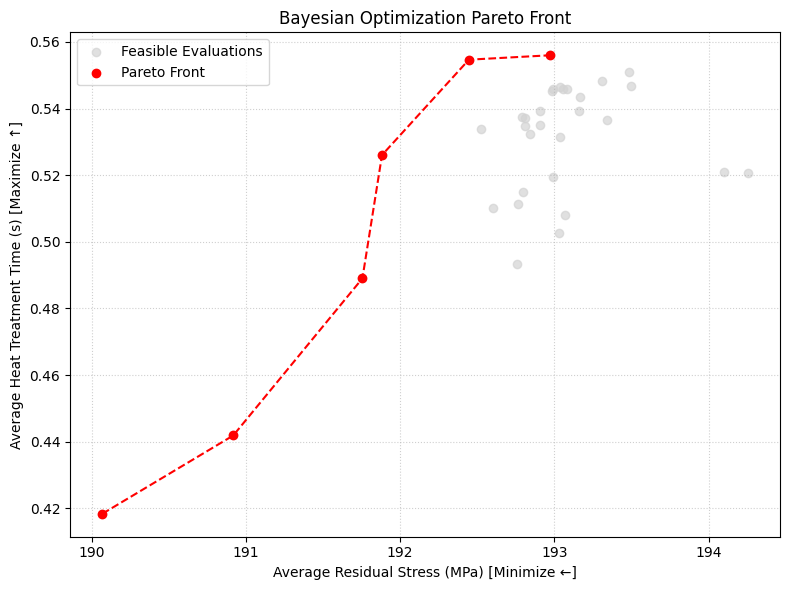

In [2]:
import matplotlib.pyplot as plt
import numpy as np

if len(feasible_X) > 0:
    # 1. Extract all feasible objectives for the background scatter
    # Multiply by -1 to convert back to true Average Stress (MPa)
    all_feasible_stress = -feasible_Y[:, 0].numpy()
    all_feasible_ht = feasible_Y[:, 1].numpy()

    # 2. Extract and sort the Pareto objectives
    pareto_stress = -best_Y[:, 0].numpy()
    pareto_ht = best_Y[:, 1].numpy()

    # Sort the Pareto points by Stress so the connecting line draws cleanly left-to-right
    sort_indices = np.argsort(pareto_stress)
    pareto_stress_sorted = pareto_stress[sort_indices]
    pareto_ht_sorted = pareto_ht[sort_indices]

    # 3. Create the Plot
    plt.figure(figsize=(8, 6))

    # Plot all feasible points in light gray
    plt.scatter(all_feasible_stress, all_feasible_ht, color='lightgray', label='Feasible Evaluations', alpha=0.7)

    # Plot Pareto optimal points in red
    plt.scatter(pareto_stress_sorted, pareto_ht_sorted, color='red', label='Pareto Front', zorder=5)
    
    # Draw a line connecting the Pareto front
    plt.plot(pareto_stress_sorted, pareto_ht_sorted, color='red', linestyle='--', zorder=4)

    # 4. Formatting
    # Note: We want to MINIMIZE stress (left is better) and MAXIMIZE HT (up is better)
    # Therefore, the "ideal" unachievable point is the top-left corner.
    plt.title("Bayesian Optimization Pareto Front")
    plt.xlabel("Average Residual Stress (MPa) [Minimize \u2190]")
    plt.ylabel("Average Heat Treatment Time (s) [Maximize \u2191]")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # Save the figure
    plt.tight_layout()
    plt.savefig("pareto_front.png", dpi=300)
    print("Saved Pareto front plot to 'pareto_front.png'.")

In [6]:
# Temporary debug test
from laser_generator import LaserProfileGenerator
from thermomechanical import run_coupled_simulation
import numpy as np

# Use a middle-of-the-road parameter set (all 0.5)
test_params = np.array([0.5]*10)
gen = LaserProfileGenerator(total_time=34.1)

# Remove the try/except here to see the actual Traceback
run_coupled_simulation(
    params=test_params,
    generator=gen,
    input_dir=".", # DOUBLE CHECK THIS PATH
    geom_file="thinwall.k",
    output_path="debug_test.zarr",
    active_print_time=34.1
)

Step 1: Loading domain and toolpath...
Time of reading input files: 0.25075316429138184
Time of calculating critical timestep: 0.022020578384399414
Time of reading and interpolating toolpath: 0.05642986297607422
Number of nodes: 23249
Number of elements: 19076
Number of time-steps: 168200
Time of generating surface: 0.09765839576721191
Step 2: Preparing material arrays...
Starting Simulation Loop (Printing: 34.1s | Cooling: 49.99999999999999s | Total: 84.1s)...
  >>> MECHANICAL SOLVE: Time 0.100s | Active Eles: 5096
  >>> MECHANICAL SOLVE: Time 0.120s | Active Eles: 5136
  >>> MECHANICAL SOLVE: Time 0.140s | Active Eles: 5156
  >>> MECHANICAL SOLVE: Time 0.160s | Active Eles: 5176
  >>> MECHANICAL SOLVE: Time 0.180s | Active Eles: 5216
  >>> MECHANICAL SOLVE: Time 0.200s | Active Eles: 5236
  >>> MECHANICAL SOLVE: Time 0.220s | Active Eles: 5276
  >>> MECHANICAL SOLVE: Time 0.240s | Active Eles: 5296
  >>> MECHANICAL SOLVE: Time 0.260s | Active Eles: 5316
  >>> MECHANICAL SOLVE: Time 0

KeyboardInterrupt: 

In [8]:
import os
import zarr
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_von_mises(S):
    """
    S: (n_e, n_q, 6) tensor of stress components
    Components: 0:xx, 1:yy, 2:zz, 3:xy, 4:yz, 5:zx
    """
    s_xx, s_yy, s_zz = S[..., 0], S[..., 1], S[..., 2]
    s_xy, s_yz, s_zx = S[..., 3], S[..., 4], S[..., 5]
    
    vm = np.sqrt(0.5 * (
        (s_xx - s_yy)**2 + (s_yy - s_zz)**2 + (s_zz - s_xx)**2 + 
        6 * (s_xy**2 + s_yz**2 + s_zx**2)
    ))
    return vm

def extract_objectives_from_zarr(zarr_path):
    try:
        z = zarr.open(zarr_path, mode='r')
        
        # 1. Stress Analysis (Final Timestep)
        # Shape: (timesteps, elements, quadrature_points, components)
        final_stress = z['stress'][-1]
        vm_stress = calculate_von_mises(final_stress)
        
        # Masking out substrate (assuming 0-index or based on birth)
        # Note: Without the .k file birth times, we take the global max/avg
        max_stress = np.max(vm_stress)
        avg_stress = np.mean(vm_stress)

        # 2. Heat Treatment Analysis
        # T_MIN_HT = 927.15K, T_MAX_HT = 1130.15K
        temp_history = z['temperature'][:] # (timesteps, nodes)
        time_history = z['time'][:]
        
        dt = np.diff(time_history, prepend=0)
        in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
        
        # Integrate time spent in band for each node
        ht_durations = np.sum(in_band * dt[:, np.newaxis], axis=0)
        
        avg_ht = np.mean(ht_durations)
        min_ht = np.min(ht_durations)

        return [avg_stress, avg_ht, min_ht, max_stress]
    except Exception as e:
        print(f"Error processing {zarr_path}: {e}")
        return [2000.0, 0.0, 0.0, 2000.0] # Penalty values

def main():
    results = []
    # Adjust range to match your total evaluations (90)
    for i in tqdm(range(90), desc="Processing Simulations"):
        zarr_file = f"stress_history_eval_{i}.zarr"
        
        if os.path.exists(zarr_file):
            metrics = extract_objectives_from_zarr(zarr_file)
            results.append({
                "eval_id": i,
                "avg_stress": metrics[0],
                "avg_ht": metrics[1],
                "min_ht": metrics[2],
                "max_stress": metrics[3],
                "feasible": (metrics[2] >= 15.0) and (metrics[3] <= 1200.0)
            })
        else:
            print(f"File {zarr_file} missing.")

    df = pd.DataFrame(results)
    df.to_csv("bo_debug_results.csv", index=False)
    print("\nSummary Statistics:")
    print(df[["avg_stress", "avg_ht", "max_stress", "feasible"]].describe())
    print(f"\nTotal Feasible Solutions: {df['feasible'].sum()}")

if __name__ == "__main__":
    main()

Processing Simulations: 100%|██████████| 90/90 [02:00<00:00,  1.34s/it]


Summary Statistics:
       avg_stress     avg_ht  max_stress
count   90.000000  90.000000   90.000000
mean   150.703461   0.225650  322.574554
std      1.698130   0.014107    3.028317
min    147.462662   0.187845  313.372925
25%    149.379620   0.215774  320.655968
50%    150.357635   0.223431  321.548431
75%    151.585827   0.234264  323.920433
max    156.943985   0.253397  329.288239

Total Feasible Solutions: 0


In [13]:
import zarr
import numpy as np

def find_cold_nodes(zarr_path, nodes_array):
    """
    nodes_array: The (N, 3) numpy array of node coordinates.
                 You must pass this in so we can cut off the substrate geometrically!
    """
    z = zarr.open(zarr_path, mode='r')
    temp_history = z['temperature'][:] 
    time_history = z['time'][:] 
    
    # --- 1. Calculate TRUE dt per save step ---
    dt_array = np.zeros_like(time_history)
    dt_array[1:] = time_history[1:] - time_history[:-1]
    
    # Reshape dt_array so we can multiply it against the (time, nodes) temperature matrix
    dt_array_2d = dt_array[:, np.newaxis]

    # --- 2. Identify the temperature band ---
    in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
    
    # --- 3. Calculate accurate cumulative time ---
    cumulative_time = np.sum(in_band * dt_array_2d, axis=0)
    
    # --- 4. GEOMETRIC SUBSTRATE FILTERING ---
    # Find the minimum Z coordinate (the bottom of the baseplate)
    min_z = np.min(nodes_array[:, 2])
    
    # Assuming the substrate is exactly 10.0mm thick (Adjust this to your actual baseplate thickness!)
    SUBSTRATE_THICKNESS = 10.0 
    
    is_deposited = nodes_array[:, 2] > (min_z + SUBSTRATE_THICKNESS + 1e-5)
    
    # --- 5. Extract Stats ---
    # Find the indices of ONLY the deposited nodes
    deposited_indices = np.where(is_deposited)[0]
    
    # Find which of those deposited nodes failed
    failed_deposited_mask = cumulative_time[deposited_indices] < 1e-6
    failed_node_indices = deposited_indices[failed_deposited_mask]
    
    print(f"Total Deposited Nodes (by geometry): {len(deposited_indices)}")
    print(f"Deposited Nodes with 0.0s Heat Treatment: {len(failed_node_indices)}")
    
    if len(failed_node_indices) > 0:
        max_temps_of_failed = np.max(temp_history[:, failed_node_indices], axis=0)
        
        too_cold = np.sum(max_temps_of_failed < 927.15)
        too_fast = np.sum(max_temps_of_failed >= 927.15) 
        
        print(f"  -> {too_cold} nodes NEVER reached the minimum 654 C.")
        print(f"  -> {too_fast} nodes reached the temperature but cooled too fast.")
        
        print(f"\nFirst 10 Failed Node Indices: {failed_node_indices[:10]}")
        print(f"Z-Heights of first 10 failed nodes: {nodes_array[failed_node_indices[:10], 2]}")
import zarr
import numpy as np
import os
from gamma.simulator.gamma import domain_mgr

def analyze_failed_nodes(zarr_path, geom_file="wall.k", input_dir="../0_properties"):
    print(f"Loading geometry via domain_mgr for exact substrate filtering...")
    domain = domain_mgr(filename=geom_file, input_data_dir=input_dir, verbose=False)
    
    # 1. Safely pull arrays to CPU
    nodes_array = domain.nodes.get() if hasattr(domain.nodes, 'get') else np.array(domain.nodes)
    node_birth = domain.node_birth.get() if hasattr(domain.node_birth, 'get') else np.array(domain.node_birth)
        
    # 2. Extract Zarr data
    z = zarr.open(zarr_path, mode='r')
    temp_history = z['temperature'][:] 
    time_history = z['time'][:] 
    
    # 3. Calculate true dt
    dt_array = np.zeros_like(time_history)
    dt_array[1:] = time_history[1:] - time_history[:-1]
    dt_array_2d = dt_array[:, np.newaxis]

    # 4. Temperature band calculation
    in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
    cumulative_time = np.sum(in_band * dt_array_2d, axis=0)
   # --- 5. EXACT SUBSTRATE & Z-HEIGHT FILTERING ---
    # Substrate is born at t < 1e-5
    # The user stopped depositing at Z = 3.0
    MAX_Z_HEIGHT = 3.0
    
    # Create a mask for nodes that are part of the active deposit up to Z=3.0
    is_active_deposit = (node_birth >= 1e-5) & (nodes_array[:, 2] <= MAX_Z_HEIGHT)
    
    active_deposit_indices = np.where(is_active_deposit)[0]
    
    deposit_cumulative_time = cumulative_time[active_deposit_indices]
    deposit_nodes = nodes_array[active_deposit_indices]
    
    # --- 6. FIND FAILURES IN THE REAL PART ---
    failed_mask = deposit_cumulative_time < 1e-6
    failed_indices_relative = np.where(failed_mask)[0] 
    
    print(f"\n{'='*40}")
    print(f" DIAGNOSTICS FOR: {zarr_path} (Capped at Z={MAX_Z_HEIGHT})")
    print(f"{'='*40}")
    print(f"Total Physically Deposited Nodes: {len(active_deposit_indices)}")
    print(f"Nodes with 0.0s HT: {len(failed_indices_relative)}")
    
    if len(failed_indices_relative) > 0:
        # Shift back to absolute indexing to read the temperature array
        abs_failed_indices = active_deposit_indices[failed_indices_relative]
        max_temps_of_failed = np.max(temp_history[:, abs_failed_indices], axis=0)
        
        too_cold = np.sum(max_temps_of_failed < 927.15)
        too_fast = np.sum(max_temps_of_failed >= 927.15)
        
        print(f"  -> {too_cold} nodes NEVER reached the minimum 654 C.")
        print(f"  -> {too_fast} nodes reached the temp but cooled too fast.")
        
        # Check Z-Heights of the failures
        failed_z_heights = deposit_nodes[failed_indices_relative, 2]
        
        print(f"\nMax Z-Height in analyzed deposit: {np.max(deposit_nodes[:, 2]):.3f}")
        print(f"Z-Heights of first 10 failed nodes: {failed_z_heights[:10].round(3)}")
        
        # See how many are strictly on the top layer
        top_layer_failures = np.sum(failed_z_heights > (MAX_Z_HEIGHT - 0.5)) 
        print(f"Failures in the top 0.5mm layer: {top_layer_failures} / {len(failed_indices_relative)}")
if __name__ == '__main__':
    # Change the zarr path to whatever iteration you are debugging
    analyze_failed_nodes("stress_history_eval_30.zarr", geom_file="wall.k", input_dir=".")

Loading geometry via domain_mgr for exact substrate filtering...

 DIAGNOSTICS FOR: stress_history_eval_30.zarr (Capped at Z=3.0)
Total Physically Deposited Nodes: 7856
Nodes with 0.0s HT: 110
  -> 110 nodes NEVER reached the minimum 654 C.
  -> 0 nodes reached the temp but cooled too fast.

Max Z-Height in analyzed deposit: 3.000
Z-Heights of first 10 failed nodes: [0.375 0.375 2.625 2.625 3.    3.    2.625 2.625 2.625 2.625]
Failures in the top 0.5mm layer: 108 / 110


Loading geometry to find nodes at Z=3.0...
Loading thermal history from stress_history_eval_38.zarr...

Found 992 nodes at Z = 3.0

--- Temperature Stats for Z = 3.0 ---
Absolute Max Temp reached by any top node: 2888.61 K
Average Max Temp of top nodes: 727.25 K
Nodes that reached 654 C (927.15 K): 238 / 992
Nodes that NEVER reached 654 C: 754 / 992

Saved temperature graph to 'top_layer_temps.png'.


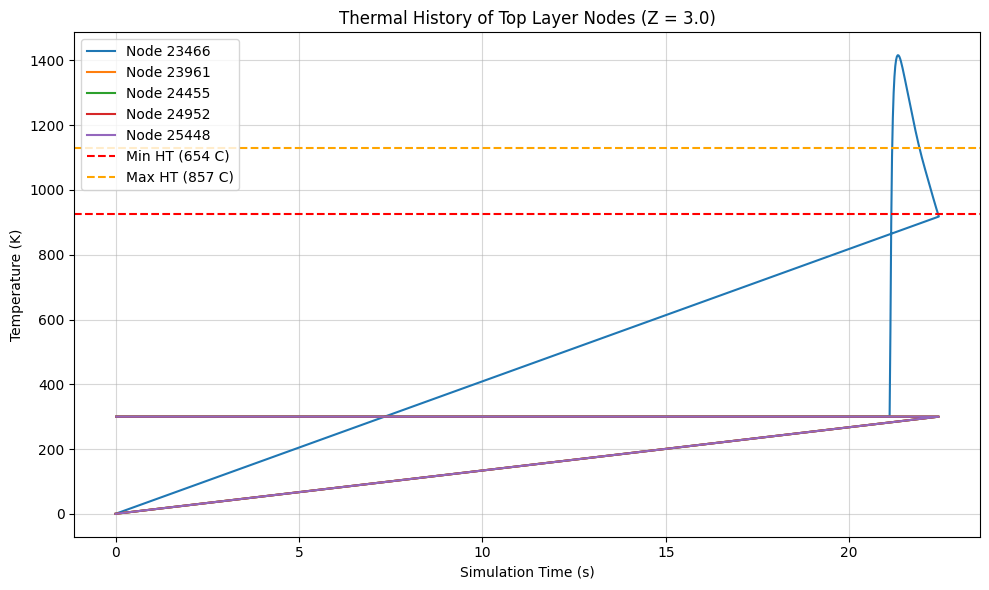

In [10]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from gamma.simulator.gamma import domain_mgr

def check_top_layer_temperature(zarr_path, geom_file="wall.k", input_dir=".", z_target=3.0):
    print(f"Loading geometry to find nodes at Z={z_target}...")
    domain = domain_mgr(filename=geom_file, input_data_dir=input_dir, verbose=False)
    nodes_array = domain.nodes.get() if hasattr(domain.nodes, 'get') else np.array(domain.nodes)
    
    print(f"Loading thermal history from {zarr_path}...")
    z = zarr.open(zarr_path, mode='r')
    temp_history = z['temperature'][:] 
    time_history = z['time'][:] 
    
    # 1. Isolate nodes exactly at the top surface
    # Using 1e-4 tolerance for floating point math
    top_layer_mask = np.abs(nodes_array[:, 2] - z_target) < 1e-4
    top_node_indices = np.where(top_layer_mask)[0]
    
    print(f"\nFound {len(top_node_indices)} nodes at Z = {z_target}")
    if len(top_node_indices) == 0:
        print("No nodes found at that exact height. Check your mesh spacing.")
        return

    # 2. Extract their temperatures
    top_temps = temp_history[:, top_node_indices]
    max_temps = np.max(top_temps, axis=0)
    
    # 3. Print Statistical Summary
    print(f"\n--- Temperature Stats for Z = {z_target} ---")
    print(f"Absolute Max Temp reached by any top node: {np.max(max_temps):.2f} K")
    print(f"Average Max Temp of top nodes: {np.mean(max_temps):.2f} K")
    print(f"Nodes that reached 654 C (927.15 K): {np.sum(max_temps >= 927.15)} / {len(top_node_indices)}")
    print(f"Nodes that NEVER reached 654 C: {np.sum(max_temps < 927.15)} / {len(top_node_indices)}")
    
    # 4. Plot the thermal history of 5 sample nodes
    plt.figure(figsize=(10, 6))
    
    # Pick 5 evenly spaced nodes along the top layer to plot
    sample_indices = np.linspace(0, len(top_node_indices) - 1, min(5, len(top_node_indices)), dtype=int)
    
    for idx in sample_indices:
        global_node_idx = top_node_indices[idx]
        plt.plot(time_history, temp_history[:, global_node_idx], label=f'Node {global_node_idx}')
        
    # Draw target heat treatment band
    plt.axhline(y=927.15, color='red', linestyle='--', label='Min HT (654 C)')
    plt.axhline(y=1130.15, color='orange', linestyle='--', label='Max HT (857 C)')
    
    plt.title(f"Thermal History of Top Layer Nodes (Z = {z_target})")
    plt.xlabel("Simulation Time (s)")
    plt.ylabel("Temperature (K)")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    
    plt.savefig("top_layer_temps.png", dpi=300)
    print("\nSaved temperature graph to 'top_layer_temps.png'.")

if __name__ == '__main__':
    check_top_layer_temperature("stress_history_eval_38.zarr")

In [11]:
import zarr
import numpy as np
import glob

def verify_all_simulations(zarr_directory=".", expected_print=27.5357, expected_total=43.0):
    print(f"{'='*60}")
    print(f" QA AUDIT: Checking Simulation Completion Dates")
    print(f"{'='*60}")
    
    zarr_files = glob.glob(f"{zarr_directory}/*.zarr")
    
    if not zarr_files:
        print("No .zarr files found. Check your directory path.")
        return

    success_count = 0
    fail_count = 0

    for z_path in sorted(zarr_files):
        try:
            z = zarr.open(z_path, mode='r')
            time_data = z['time'][:]
            
            # Filter out the pre-allocated zeros (ignoring the literal t=0 start)
            valid_times = time_data[1:][time_data[1:] > 1e-6]
            
            if len(valid_times) == 0:
                print(f"[!] {z_path:30} -> FAILED (No valid time steps recorded)")
                fail_count += 1
                continue
                
            final_recorded_time = valid_times[-1]
            
            if final_recorded_time >= expected_total - 0.5: # 0.5s tolerance for dt landing
                print(f"[OK] {z_path:30} -> COMPLETED (Ended at {final_recorded_time:.3f}s)")
                success_count += 1
            elif final_recorded_time >= expected_print:
                print(f"[~] {z_path:30} -> DIED IN COOLING (Ended at {final_recorded_time:.3f}s)")
                fail_count += 1
            else:
                print(f"[X] {z_path:30} -> DIED PRINTING (Ended at {final_recorded_time:.3f}s)")
                fail_count += 1
                
        except Exception as e:
            print(f"[!] {z_path:30} -> CORRUPTED OR UNREADABLE: {e}")
            fail_count += 1

    print(f"\n{'='*60}")
    print(f" QA SUMMARY: {success_count} Passed | {fail_count} Failed")
    print(f"{'='*60}")

if __name__ == '__main__':
    verify_all_simulations()

 QA AUDIT: Checking Simulation Completion Dates
[OK] ./stress_history_eval_0.zarr   -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_1.zarr   -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_10.zarr  -> COMPLETED (Ended at 42.856s)
[OK] ./stress_history_eval_11.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_12.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_13.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_14.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_15.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_16.zarr  -> COMPLETED (Ended at 42.676s)
[OK] ./stress_history_eval_17.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_18.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_19.zarr  -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_2.zarr   -> COMPLETED (Ended at 42.996s)
[OK] ./stress_history_eval_20.zarr  -> COMPLETED (Ended at 42.996s)
